# StreamFlix Content Analytics Project

## Phase 2 – Exploratory Data Analysis

**Analyst:** Hemanth

### Objective
The objective of Phase 2 is to explore viewing, content, subscriber, device, and review patterns using visualizations and identify meaningful business insights.

In [1]:
import pandas as pd

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
watch_history = pd.read_csv(
    "../cleaned_data/watch_history_cleaned.csv",
    parse_dates=["watch_date"]
)

In [4]:
watch_history.shape

(650000, 10)

In [5]:
watch_history['watch_date'].dtype

dtype('<M8[us]')

In [6]:
monthly_sessions = (
    watch_history
    .groupby(watch_history['watch_date'].dt.to_period('M'))
    .size()
    .sort_index()
)

monthly_sessions.head()

watch_date
2017-03    1
2017-04    1
2017-05    1
2017-07    1
2017-09    2
Freq: M, dtype: int64

In [7]:
busiest_month = monthly_sessions.idxmax()
busiest_sessions = monthly_sessions.max()

print("Busiest month:", busiest_month)
print("Number of sessions:", busiest_sessions)

Busiest month: 2026-05
Number of sessions: 224696


## Chart 1 – Monthly Viewing Volume

This analysis examines the number of viewing sessions recorded each month across the StreamFlix platform timeline.

In [8]:
monthly_sessions_plot = monthly_sessions.copy()
monthly_sessions_plot.index = monthly_sessions_plot.index.to_timestamp()

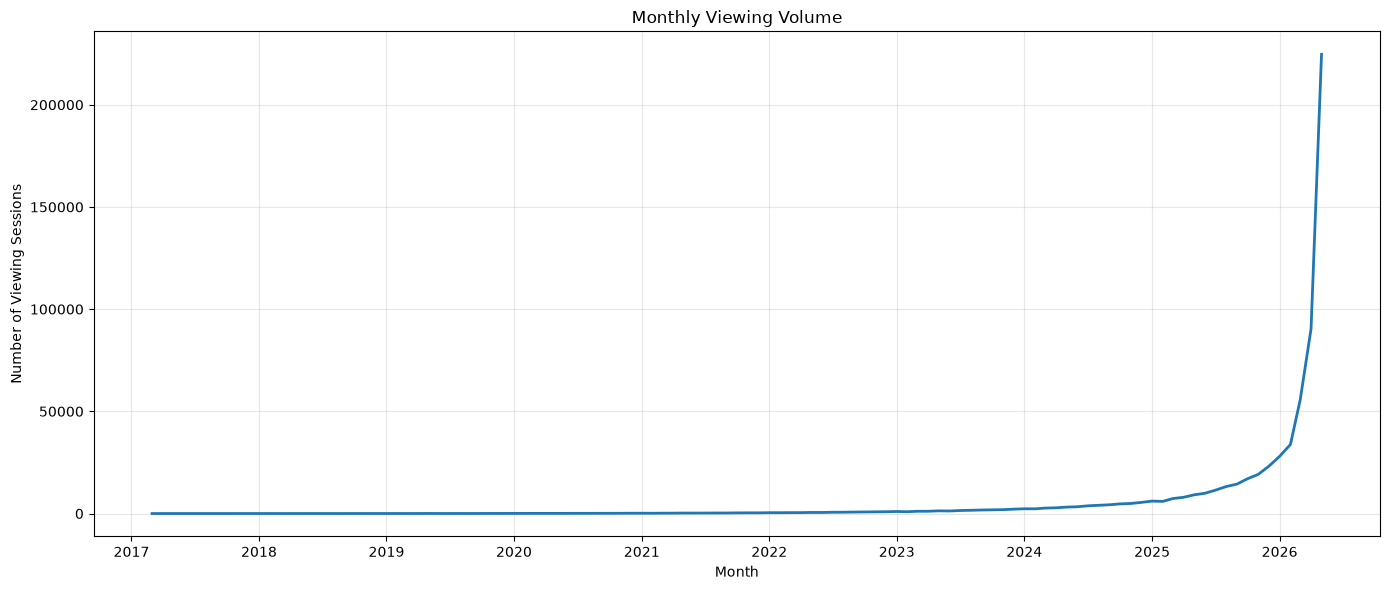

In [9]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sessions_plot.index,
    monthly_sessions_plot.values,
    linewidth=2
)

plt.title("Monthly Viewing Volume")
plt.xlabel("Month")
plt.ylabel("Number of Viewing Sessions")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

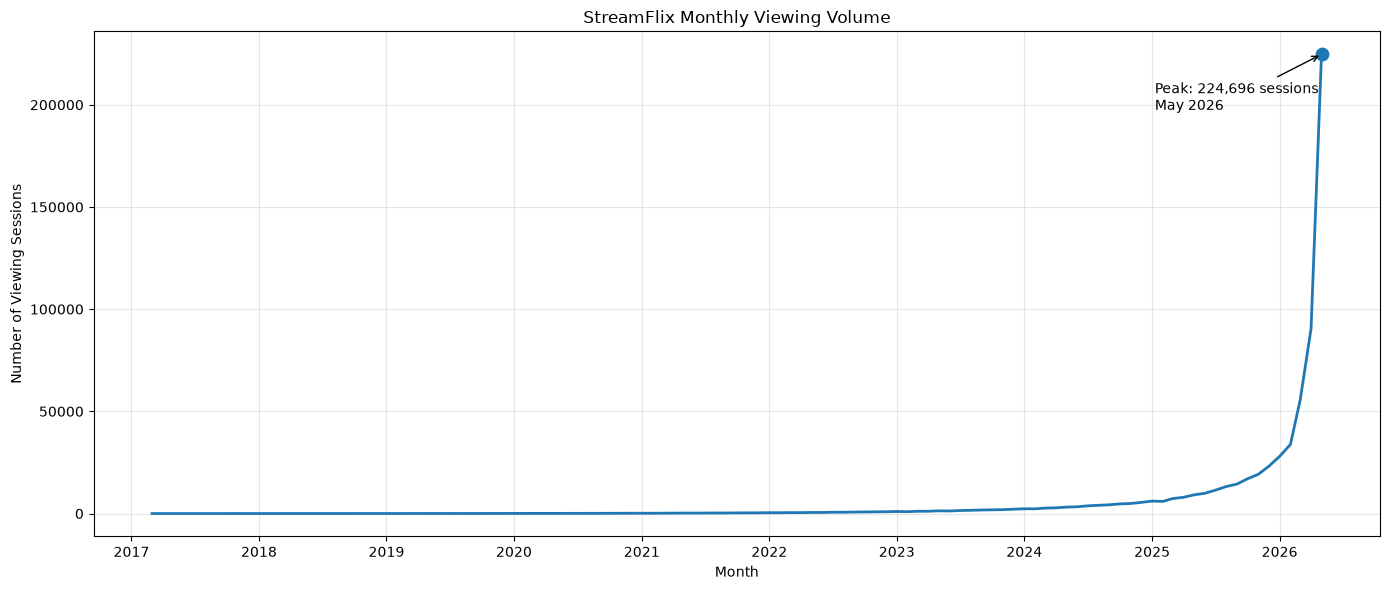

In [10]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sessions_plot.index,
    monthly_sessions_plot.values,
    linewidth=2
)

busiest_date = busiest_month.to_timestamp()

plt.scatter(
    busiest_date,
    busiest_sessions,
    s=80
)

plt.annotate(
    f"Peak: {busiest_sessions:,} sessions\nMay 2026",
    xy=(busiest_date, busiest_sessions),
    xytext=(-120, -40),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.title("StreamFlix Monthly Viewing Volume")
plt.xlabel("Month")
plt.ylabel("Number of Viewing Sessions")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../charts/01_monthly_viewing_volume.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Observation

Monthly viewing activity increased substantially over the StreamFlix timeline, with the strongest growth occurring during 2025 and 2026. The busiest month was May 2026, recording 224,696 viewing sessions. This indicates a sharp acceleration in platform engagement toward the end of the available data period.

## Chart 2 – Monthly Watch Hours Trend

This analysis examines the total number of watch hours generated each month across the StreamFlix platform timeline.

In [11]:
monthly_watch_hours = (
    watch_history
    .groupby(watch_history['watch_date'].dt.to_period('M'))['watch_duration_min']
    .sum()
    .div(60)
    .sort_index()
)

monthly_watch_hours.head()

watch_date
2017-03     4.773333
2017-04     4.400000
2017-05    14.416667
2017-07     1.413333
2017-09     2.610000
Freq: M, Name: watch_duration_min, dtype: float64

In [12]:
peak_watch_month = monthly_watch_hours.idxmax()
peak_watch_hours = monthly_watch_hours.max()

print("Peak watch-hours month:", peak_watch_month)
print("Total watch hours:", round(peak_watch_hours, 2))

Peak watch-hours month: 2026-05
Total watch hours: 1157785.9


In [13]:
monthly_watch_hours_plot = monthly_watch_hours.copy()
monthly_watch_hours_plot.index = monthly_watch_hours_plot.index.to_timestamp()

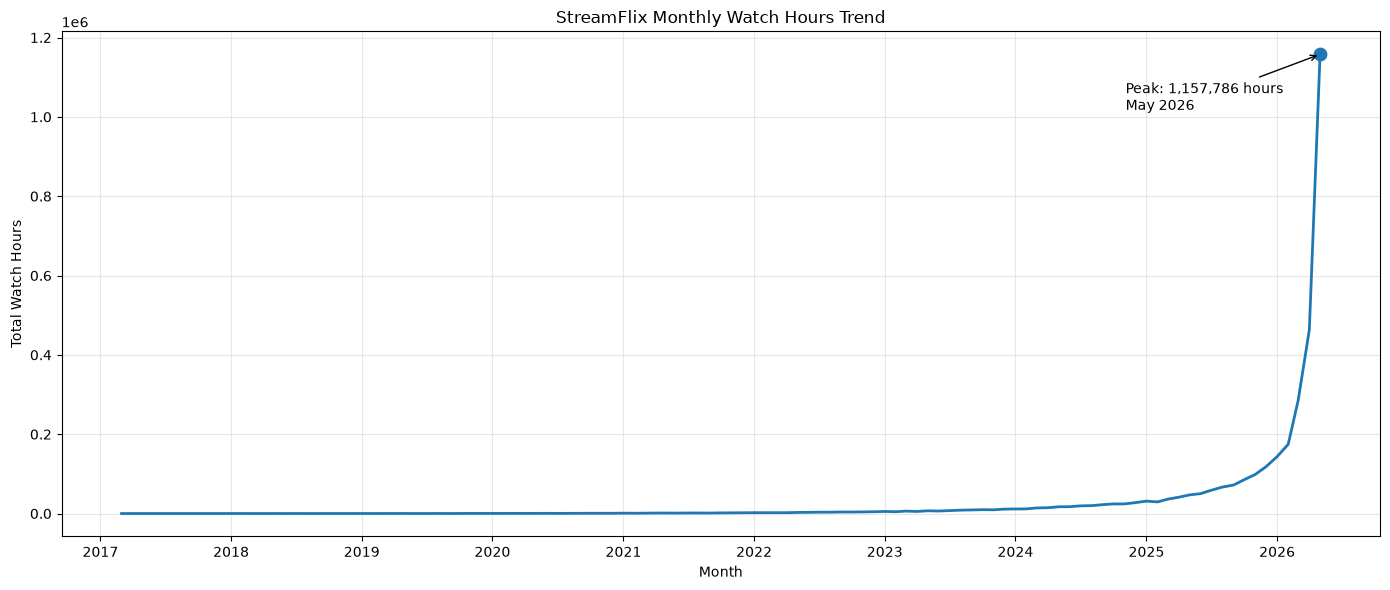

In [14]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_watch_hours_plot.index,
    monthly_watch_hours_plot.values,
    linewidth=2
)

peak_watch_date = peak_watch_month.to_timestamp()

plt.scatter(
    peak_watch_date,
    peak_watch_hours,
    s=80
)

plt.annotate(
    f"Peak: {peak_watch_hours:,.0f} hours\nMay 2026",
    xy=(peak_watch_date, peak_watch_hours),
    xytext=(-140, -40),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.title("StreamFlix Monthly Watch Hours Trend")
plt.xlabel("Month")
plt.ylabel("Total Watch Hours")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../charts/02_monthly_watch_hours_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Monthly watch hours increased substantially over the StreamFlix timeline, with the strongest growth occurring during 2025 and 2026. May 2026 recorded the highest watch time at approximately 1.16 million hours. The watch-hours trend closely follows the growth in viewing sessions, indicating a major increase in overall platform engagement toward the end of the dataset.

In [15]:
yearly_watch_hours = (
    watch_history
    .groupby(watch_history['watch_date'].dt.year)['watch_duration_min']
    .sum()
    .div(60)
)

yearly_watch_hours

watch_date
2017    4.575667e+01
2018    5.835400e+02
2019    1.679413e+03
2020    5.471778e+03
2021    1.543533e+04
2022    3.735396e+04
2023    8.966582e+04
2024    2.239940e+05
2025    7.339391e+05
2026    2.225299e+06
Name: watch_duration_min, dtype: float64

In [16]:
yoy_comparison = pd.DataFrame({
    'Watch Hours': yearly_watch_hours,
    'YoY Growth %': yearly_watch_hours.pct_change() * 100
})

yoy_comparison.round(2)

,Watch Hours,YoY Growth %
watch_date,,
2017,45.76,NaN
2018,583.54,1175.31
2019,1679.41,187.80
2020,5471.78,225.81
2021,15435.33,182.09
2022,37353.96,142.00
2023,89665.82,140.04
2024,223994.05,149.81
2025,733939.06,227.66


In [17]:
jan_jun_data = watch_history[
    watch_history['watch_date'].dt.month <= 6
]

jan_jun_watch_hours = (
    jan_jun_data
    .groupby(jan_jun_data['watch_date'].dt.year)['watch_duration_min']
    .sum()
    .div(60)
)

jan_jun_watch_hours.loc[[2025, 2026]]

watch_date
2025    2.349147e+05
2026    2.225299e+06
Name: watch_duration_min, dtype: float64

In [18]:
watch_hours_2025 = jan_jun_watch_hours.loc[2025]
watch_hours_2026 = jan_jun_watch_hours.loc[2026]

yoy_growth_2026 = (
    (watch_hours_2026 - watch_hours_2025)
    / watch_hours_2025
) * 100

print("Jan-Jun 2025 Watch Hours:", round(watch_hours_2025, 2))
print("Jan-Jun 2026 Watch Hours:", round(watch_hours_2026, 2))
print("YoY Growth:", round(yoy_growth_2026, 2), "%")

Jan-Jun 2025 Watch Hours: 234914.71
Jan-Jun 2026 Watch Hours: 2225299.02
YoY Growth: 847.28 %


### Observation

Monthly watch hours increased sharply over the StreamFlix timeline, with the strongest acceleration occurring during 2025 and 2026. May 2026 recorded the highest monthly watch time at approximately 1.16 million hours. Comparing the same January–June period, watch hours increased from approximately 234,915 hours in 2025 to 2.23 million hours in 2026, representing year-over-year growth of about 847.28%.

## Chart 3 – Genre-wise Watch Hours Share

This analysis compares total watch hours across content genres to identify which genres generate the highest viewer engagement.

In [19]:
titles = pd.read_csv(
    "../cleaned_data/titles_cleaned.csv",
    parse_dates=["date_added", "license_expiry"]
)

In [20]:
titles.shape

(9000, 21)

In [21]:
watch_with_titles = pd.merge(
    watch_history,
    titles,
    on="title_id",
    how="left"
)

In [22]:
watch_with_titles.shape

(650000, 30)

In [23]:
watch_with_titles[
    ['title_id', 'watch_duration_min', 'title_name', 'primary_genre', 'type']
].head()

,title_id,watch_duration_min,title_name,primary_genre,type
0,TTL205207,826.7,Naples Legacy II,Comedy,TV Show
1,TTL204889,1866.4,The Reckoning of Lagos II,Drama,TV Show
2,TTL206882,75.0,The Lighthouse of Hamburg II,Comedy,TV Show
3,TTL208849,493.2,The Odyssey of Madrid II,Horror,TV Show
4,TTL202529,94.6,The Storm of Lisbon III,Action,Movie


In [24]:
watch_with_titles.shape

(650000, 30)

In [25]:
genre_watch_hours = (
    watch_with_titles
    .groupby('primary_genre')['watch_duration_min']
    .sum()
    .div(60)
    .sort_values(ascending=False)
)

genre_watch_hours

primary_genre
Drama            501884.466667
Comedy           423149.053333
Action           393171.916667
Thriller         307024.663333
Documentary      291216.898333
Crime            237435.838333
Romance          214332.301667
Animation        180093.938333
Sci-Fi           154332.208333
Horror           138033.605000
Fantasy          127838.850000
Reality          103954.906667
Kids & Family    103118.066667
Mystery           82552.373333
Musical           39023.391667
Stand-Up          36305.255000
Name: watch_duration_min, dtype: float64

In [26]:
top_genre = genre_watch_hours.idxmax()
top_genre_hours = genre_watch_hours.max()

print("Top genre:", top_genre)
print("Watch hours:", round(top_genre_hours, 2))

Top genre: Drama
Watch hours: 501884.47


In [27]:
genre_share_pct = (
    genre_watch_hours / genre_watch_hours.sum() * 100
)

genre_share_pct.round(2)

primary_genre
Drama            15.06
Comedy           12.69
Action           11.79
Thriller          9.21
Documentary       8.74
Crime             7.12
Romance           6.43
Animation         5.40
Sci-Fi            4.63
Horror            4.14
Fantasy           3.84
Reality           3.12
Kids & Family     3.09
Mystery           2.48
Musical           1.17
Stand-Up          1.09
Name: watch_duration_min, dtype: float64

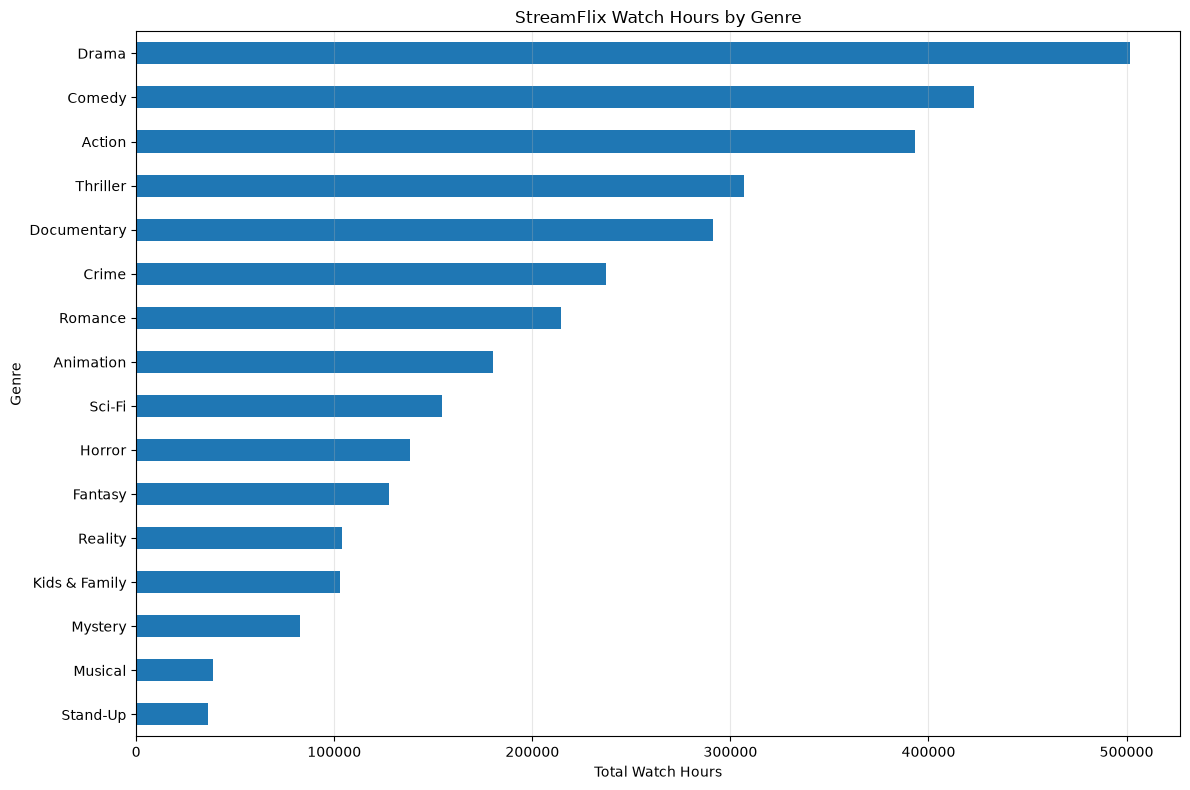

In [28]:
plt.figure(figsize=(12, 8))

genre_watch_hours.sort_values().plot(
    kind="barh"
)

plt.title("StreamFlix Watch Hours by Genre")
plt.xlabel("Total Watch Hours")
plt.ylabel("Genre")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../charts/03_genre_watch_hours.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
genre_share_pct.round(2)

primary_genre
Drama            15.06
Comedy           12.69
Action           11.79
Thriller          9.21
Documentary       8.74
Crime             7.12
Romance           6.43
Animation         5.40
Sci-Fi            4.63
Horror            4.14
Fantasy           3.84
Reality           3.12
Kids & Family     3.09
Mystery           2.48
Musical           1.17
Stand-Up          1.09
Name: watch_duration_min, dtype: float64

### Observation

Drama generated the highest share of StreamFlix watch time at 15.06%, followed by Comedy at 12.69% and Action at 11.79%. In contrast, Stand-Up and Musical recorded the lowest watch-hour shares at 1.09% and 1.17%, respectively. This suggests that Drama, Comedy, and Action are the strongest engagement-driving genres, while the lowest-ranked genres attract substantially less viewing time.

## Chart 4 – Content Type Watch Hours Split

This analysis compares the share of total watch hours generated by Movies and TV Shows on StreamFlix.

In [30]:
content_type_hours = (
    watch_with_titles
    .groupby('type')['watch_duration_min']
    .sum()
    .div(60)
    .sort_values(ascending=False)
)

content_type_hours

type
TV Show    2.882609e+06
Movie      4.508588e+05
Name: watch_duration_min, dtype: float64

In [31]:
content_type_share = (
    content_type_hours / content_type_hours.sum() * 100
)

content_type_share.round(2)

type
TV Show    86.47
Movie      13.53
Name: watch_duration_min, dtype: float64

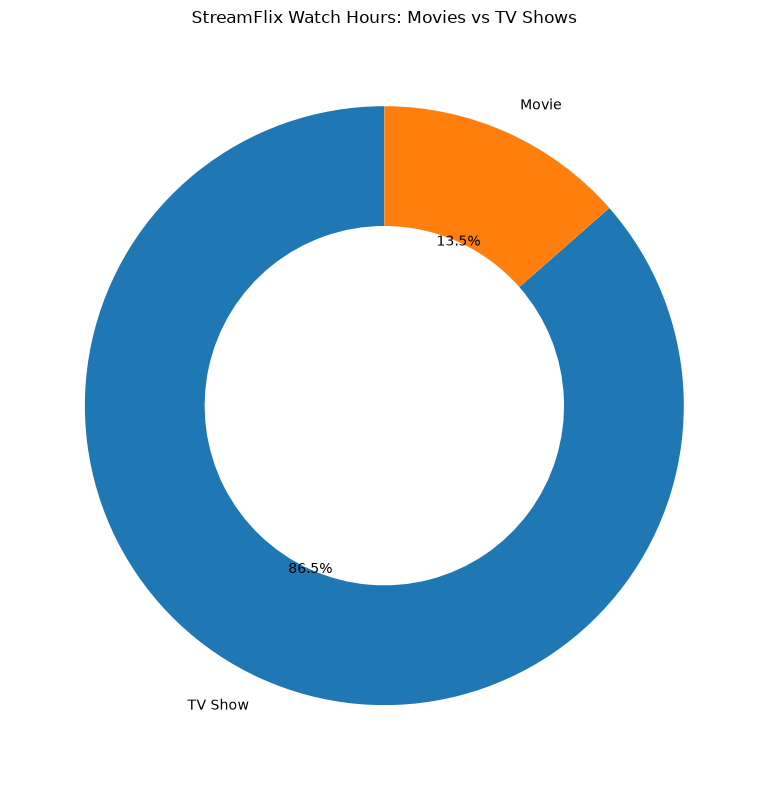

In [32]:
plt.figure(figsize=(8, 8))

plt.pie(
    content_type_hours.values,
    labels=content_type_hours.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.4}
)

plt.title("StreamFlix Watch Hours: Movies vs TV Shows")

plt.tight_layout()

plt.savefig(
    "../charts/04_content_type_split.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

TV Shows account for 86.47% of total StreamFlix watch hours, while Movies contribute only 13.53%. This indicates that long-form or episodic TV content drives the vast majority of viewing engagement on the platform. StreamFlix may therefore benefit from prioritizing strong TV series while still maintaining a balanced movie catalogue.

## Chart 5 – Top 10 Countries by Watch Hours

This analysis identifies the subscriber countries generating the highest total watch hours on StreamFlix.

In [33]:
subscribers = pd.read_csv(
    "../cleaned_data/subscribers_cleaned.csv",
    parse_dates=["signup_date", "churn_date"]
)

In [34]:
subscribers.shape

(15000, 14)

In [35]:
watch_with_subscribers = pd.merge(
    watch_history,
    subscribers[['subscriber_id', 'country']],
    on="subscriber_id",
    how="left"
)

In [36]:
watch_with_subscribers[
    ['subscriber_id', 'country', 'watch_duration_min']
].head()

,subscriber_id,country,watch_duration_min
0,SUB107630,South Korea,826.7
1,SUB114773,India,1866.4
2,SUB106013,Brazil,75.0
3,SUB100939,United States,493.2
4,SUB107223,United States,94.6


In [37]:
country_watch_hours = (
    watch_with_subscribers
    .groupby('country')['watch_duration_min']
    .sum()
    .div(60)
    .sort_values(ascending=False)
)

top_10_countries = country_watch_hours.head(10)

top_10_countries

country
United States     910551.198333
India             380917.681667
United Kingdom    285346.350000
South Korea       239498.930000
Brazil            206648.200000
Japan             171707.983333
France            167418.188333
Mexico            143971.786667
Spain             137107.413333
Germany           136936.378333
Name: watch_duration_min, dtype: float64

In [38]:
top_country = top_10_countries.idxmax()
top_country_hours = top_10_countries.max()

print("Top country:", top_country)
print("Watch hours:", round(top_country_hours, 2))


Top country: United States
Watch hours: 910551.2


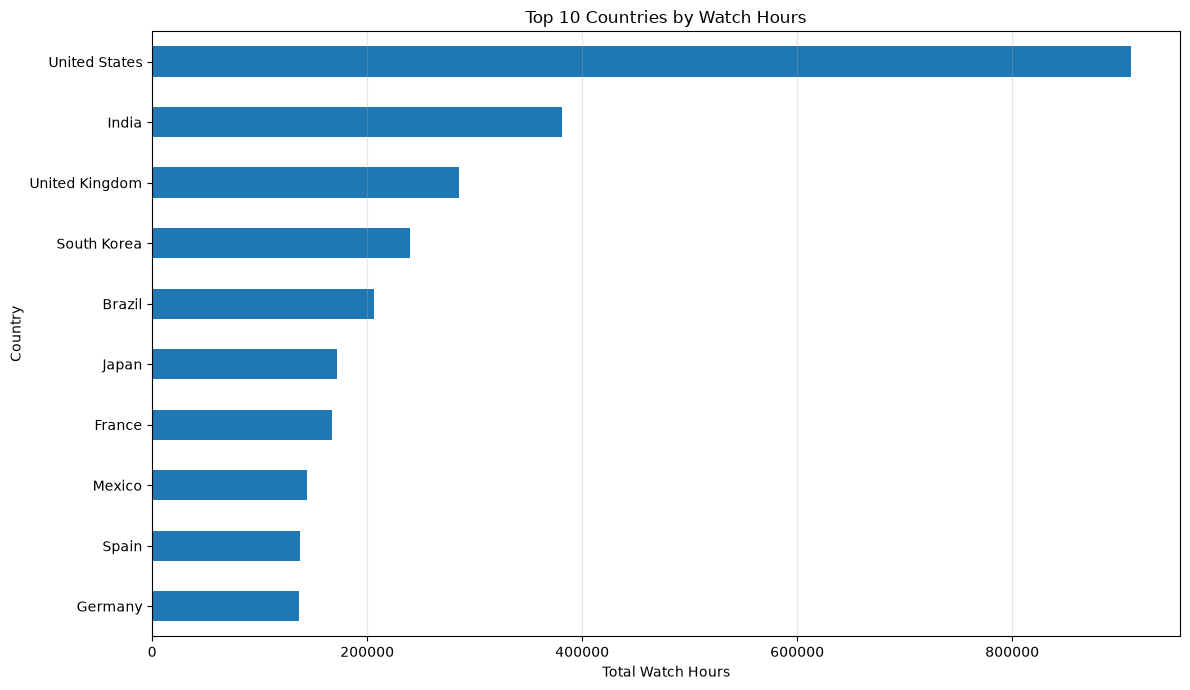

In [39]:
plt.figure(figsize=(12, 7))

top_10_countries.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Countries by Watch Hours")
plt.xlabel("Total Watch Hours")
plt.ylabel("Country")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../charts/05_top_10_countries_watch_hours.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [40]:
top_10_countries


country
United States     910551.198333
India             380917.681667
United Kingdom    285346.350000
South Korea       239498.930000
Brazil            206648.200000
Japan             171707.983333
France            167418.188333
Mexico            143971.786667
Spain             137107.413333
Germany           136936.378333
Name: watch_duration_min, dtype: float64

### Observation

The United States is the largest StreamFlix market by viewing activity, generating approximately 910,551 watch hours, more than twice India's 380,918 hours in second place. The United Kingdom, South Korea, and Brazil complete the top five markets. This indicates that StreamFlix engagement is strongest in the United States, while India and several international markets also contribute substantial viewing activity.

## Chart 6 – Subscriber Plan Distribution

This analysis examines how StreamFlix subscribers are distributed across the Basic with Ads, Standard, and Premium subscription plans.

In [41]:
plan_distribution = subscribers['plan_type'].value_counts()

plan_distribution

plan_type
Standard          6100
Basic with Ads    4458
Premium           4442
Name: count, dtype: int64

In [42]:
plan_share = (
    plan_distribution / plan_distribution.sum() * 100
)

plan_share.round(2)

plan_type
Standard          40.67
Basic with Ads    29.72
Premium           29.61
Name: count, dtype: float64

In [43]:
plan_share.round(2)

plan_type
Standard          40.67
Basic with Ads    29.72
Premium           29.61
Name: count, dtype: float64

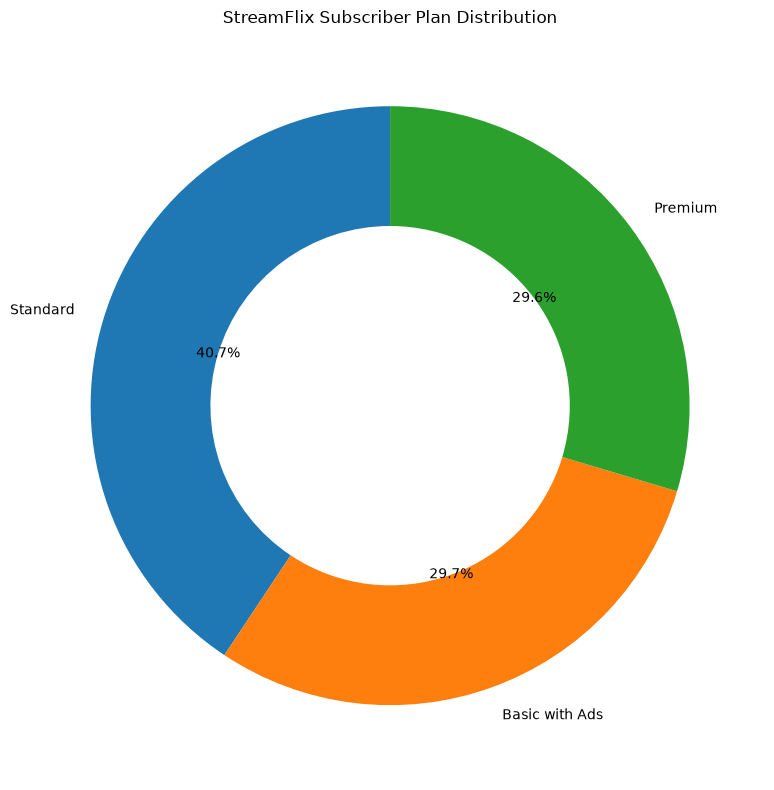

In [44]:
plt.figure(figsize=(8, 8))

plt.pie(
    plan_distribution.values,
    labels=plan_distribution.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.4}
)

plt.title("StreamFlix Subscriber Plan Distribution")

plt.tight_layout()

plt.savefig(
    "../charts/06_subscriber_plan_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The Standard plan has the largest subscriber share at 40.67%, while Basic with Ads and Premium account for 29.72% and 29.61%, respectively. The near-equal shares of Basic and Premium suggest that StreamFlix has a relatively balanced mix of budget-conscious and higher-value subscribers, while Standard remains the most popular option.

## Chart 7 – Device Usage

This analysis examines the distribution of viewing sessions across different device types used on StreamFlix.

In [45]:
device_usage = watch_history['device'].value_counts()

device_usage

device
Smart TV           221446
Mobile             175605
Laptop              96408
Tablet              65276
Game Console        52322
Streaming Stick     38943
Name: count, dtype: int64

In [46]:
device_share = (
    device_usage / device_usage.sum() * 100
)

device_share.round(2)

device
Smart TV           34.07
Mobile             27.02
Laptop             14.83
Tablet             10.04
Game Console        8.05
Streaming Stick     5.99
Name: count, dtype: float64

In [47]:
device_share.round(2)

device
Smart TV           34.07
Mobile             27.02
Laptop             14.83
Tablet             10.04
Game Console        8.05
Streaming Stick     5.99
Name: count, dtype: float64

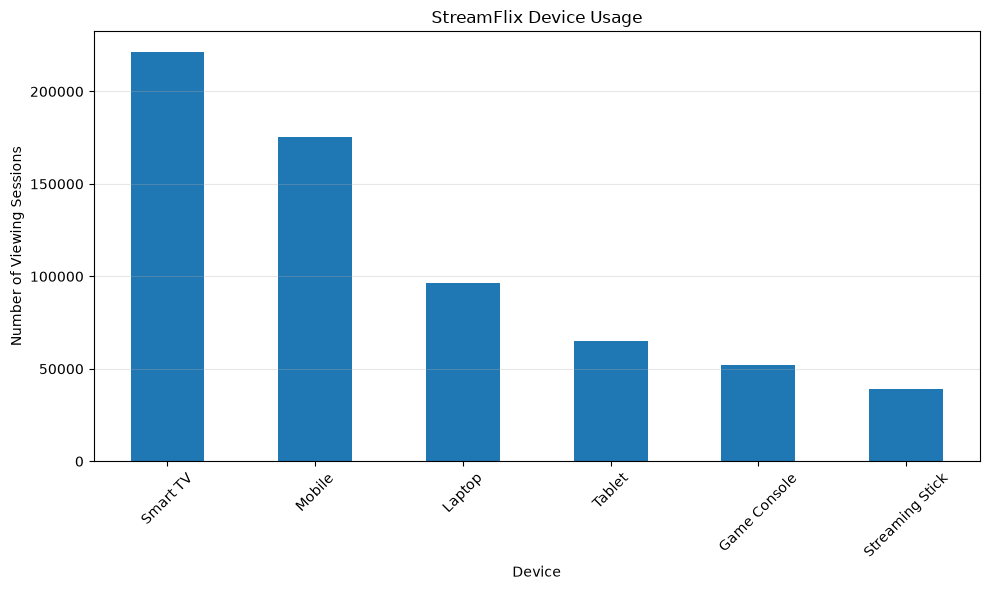

In [48]:
plt.figure(figsize=(10, 6))

device_usage.plot(
    kind="bar"
)

plt.title("StreamFlix Device Usage")
plt.xlabel("Device")
plt.ylabel("Number of Viewing Sessions")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../charts/07_device_usage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Smart TV is the most commonly used device on StreamFlix, accounting for 34.07% of viewing sessions, followed by Mobile at 27.02%. Together, these two device types represent more than 60% of total viewing activity. Streaming Stick has the lowest usage share at 5.99%, indicating that most viewers prefer larger-screen Smart TVs or mobile devices.

## Chart 8 – Age Distribution of Subscribers

This analysis examines the age distribution of StreamFlix subscribers to understand which age groups make up the largest share of the customer base.

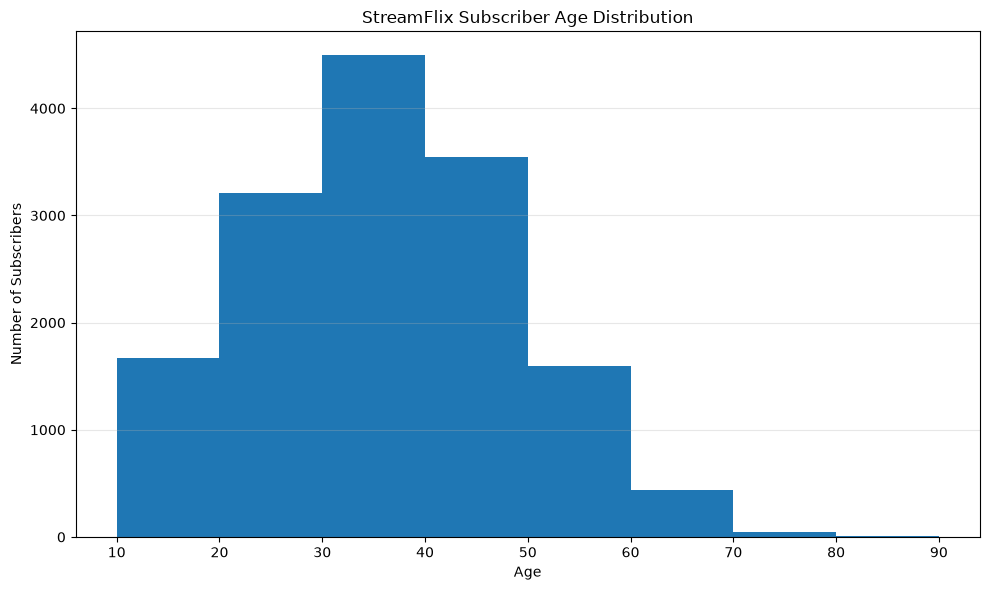

In [49]:
plt.figure(figsize=(10, 6))

plt.hist(
    subscribers['age'],
    bins=range(10, 91, 10)
)

plt.title("StreamFlix Subscriber Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Subscribers")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../charts/08_subscriber_age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [50]:
age_groups = pd.cut(
    subscribers['age'],
    bins=[12, 19, 29, 39, 49, 59, 69, 79, 85],
    labels=[
        '13-19',
        '20-29',
        '30-39',
        '40-49',
        '50-59',
        '60-69',
        '70-79',
        '80-85'
    ]
)

age_group_counts = age_groups.value_counts().sort_index()

age_group_counts

age
13-19    1666
20-29    3208
30-39    4494
40-49    3546
50-59    1593
60-69     438
70-79      49
80-85       6
Name: count, dtype: int64

In [51]:
watch_with_age = pd.merge(
    watch_history,
    subscribers[['subscriber_id', 'age']],
    on='subscriber_id',
    how='left'
)

In [52]:
watch_with_age['age_group'] = pd.cut(
    watch_with_age['age'],
    bins=[12, 19, 29, 39, 49, 59, 69, 79, 85],
    labels=[
        '13-19',
        '20-29',
        '30-39',
        '40-49',
        '50-59',
        '60-69',
        '70-79',
        '80-85'
    ]
)

In [53]:
age_group_watch_hours = (
    watch_with_age
    .groupby('age_group', observed=True)['watch_duration_min']
    .sum()
    .div(60)
    .sort_values(ascending=False)
)

age_group_watch_hours.round(2)

age_group
30-39    1001949.58
40-49     850402.10
20-29     644609.73
50-59     373724.25
13-19     368467.55
60-69      85039.03
70-79       8669.81
80-85        605.68
Name: watch_duration_min, dtype: float64

In [54]:
age_group_watch_hours.round(2)

age_group
30-39    1001949.58
40-49     850402.10
20-29     644609.73
50-59     373724.25
13-19     368467.55
60-69      85039.03
70-79       8669.81
80-85        605.68
Name: watch_duration_min, dtype: float64

### Observation

Subscribers aged 30–39 form the largest customer segment with 4,494 subscribers and also generate the highest total watch time at approximately 1.00 million hours. The 40–49 age group ranks second with about 850,402 watch hours, followed by the 20–29 group with about 644,610 hours. This indicates that subscribers between 30 and 49 years old are the strongest engagement segment on StreamFlix.

## Chart 9 – Completion Rate by Genre

This analysis compares the average content completion percentage across StreamFlix genres to identify which genres viewers are most likely to finish.

In [55]:
genre_completion = (
    watch_with_titles
    .groupby('primary_genre')['completion_pct']
    .mean()
    .sort_values(ascending=False)
)

genre_completion.round(2)

primary_genre
Musical          66.83
Animation        66.38
Stand-Up         66.32
Fantasy          65.97
Sci-Fi           65.79
Mystery          65.56
Crime            65.46
Comedy           65.32
Kids & Family    65.31
Thriller         65.31
Horror           65.26
Documentary      65.13
Drama            65.10
Romance          65.00
Action           64.81
Reality          64.70
Name: completion_pct, dtype: float64

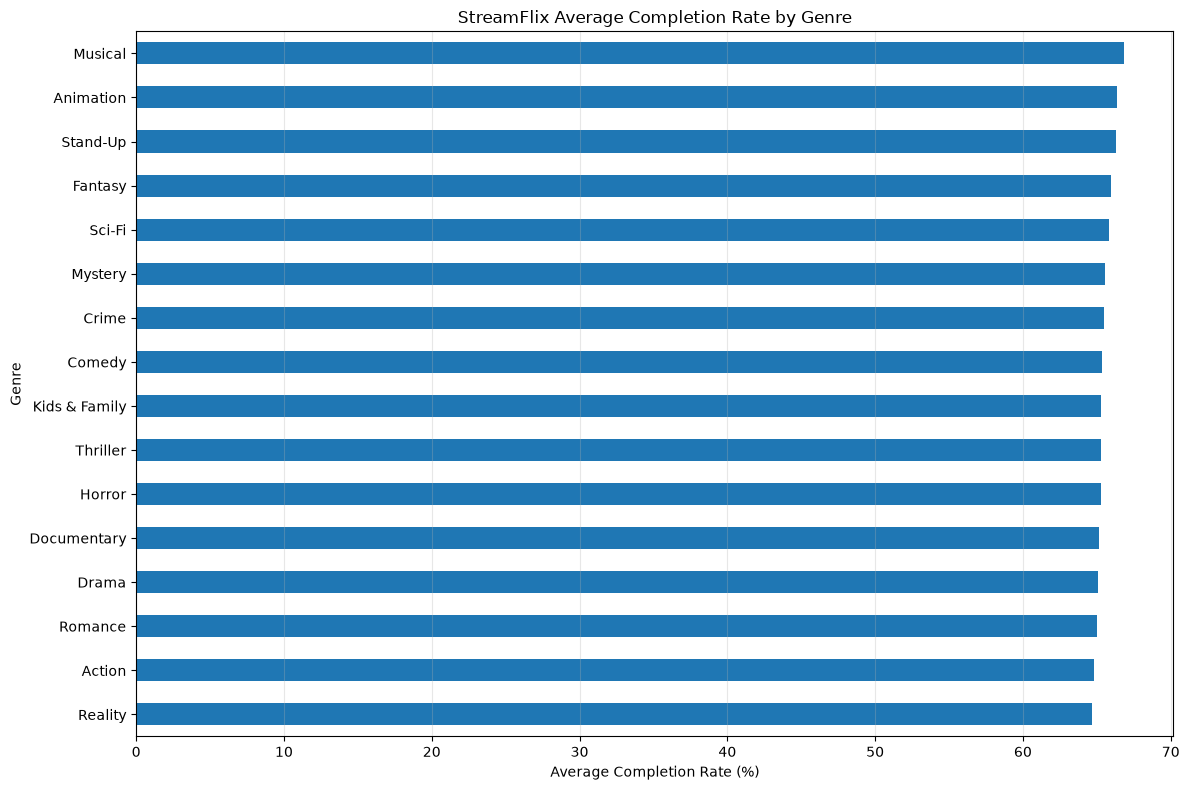

In [56]:
plt.figure(figsize=(12, 8))

genre_completion.sort_values().plot(
    kind="barh"
)

plt.title("StreamFlix Average Completion Rate by Genre")
plt.xlabel("Average Completion Rate (%)")
plt.ylabel("Genre")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../charts/09_completion_rate_by_genre.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Musical content has the highest average completion rate at 66.83%, followed by Animation at 66.38% and Stand-Up at 66.32%. Reality records the lowest average completion rate at 64.70%, followed by Action at 64.81%. However, the difference between the highest and lowest genres is only about 2.13 percentage points, indicating that completion behavior is relatively consistent across genres.

## Chart 10 – Review Sentiment Breakdown

This analysis examines the distribution of Positive, Neutral, and Negative written reviews submitted by StreamFlix subscribers.

In [57]:
reviews = pd.read_csv(
    "../cleaned_data/reviews_cleaned.csv",
    parse_dates=["review_date"]
)

In [58]:
sentiment_counts = reviews['sentiment'].value_counts()

sentiment_counts

sentiment
Positive    75007
Neutral     22759
Negative    12234
Name: count, dtype: int64

In [59]:
sentiment_share = (
    sentiment_counts / sentiment_counts.sum() * 100
)

sentiment_share.round(2)

sentiment
Positive    68.19
Neutral     20.69
Negative    11.12
Name: count, dtype: float64

In [60]:
sentiment_share.round(2)

sentiment
Positive    68.19
Neutral     20.69
Negative    11.12
Name: count, dtype: float64

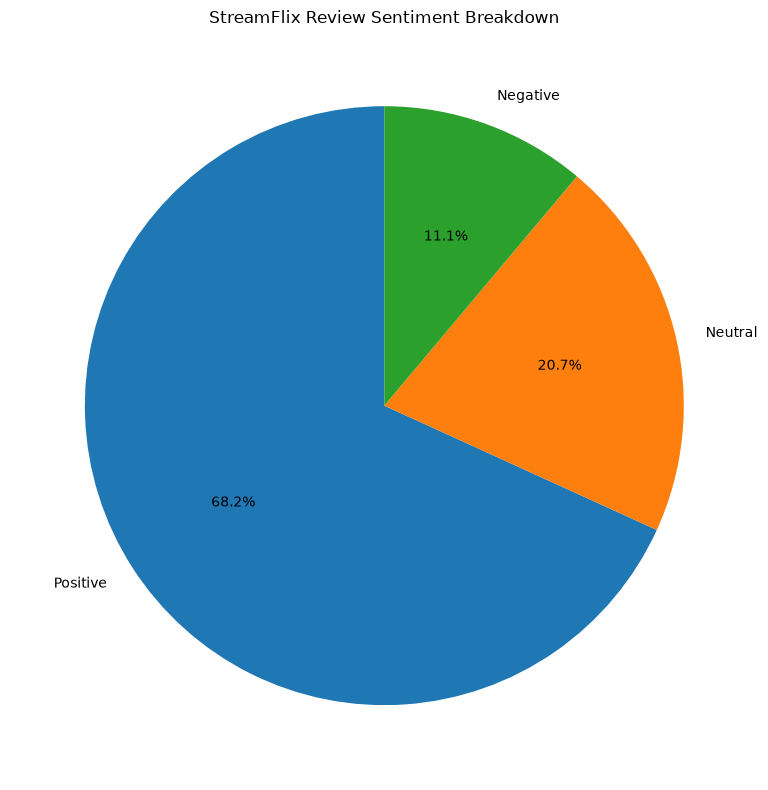

In [61]:
plt.figure(figsize=(8, 8))

plt.pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("StreamFlix Review Sentiment Breakdown")

plt.tight_layout()

plt.savefig(
    "../charts/10_review_sentiment_breakdown.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Positive reviews dominate StreamFlix customer feedback, accounting for 68.19% of all written reviews. Neutral reviews represent 20.69%, while Negative reviews account for only 11.12%. This indicates that overall subscriber sentiment is largely positive, although the negative review segment should still be monitored for recurring customer-experience issues.